In [25]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import folium
from folium.plugins import HeatMap
import h3
from shapely.geometry import Polygon

In [4]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Check data                              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Path relative to the root directory
file_path = "../../data/trips/trips_cleaned_V1.csv"

trip_data = pd.read_csv(file_path)
trip_data.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,dropoff_centroid_location,pickup_h3_low_resolution,dropoff_h3_low_resolution,pickup_h3_medium_resolution,dropoff_h3_medium_resolution,pickup_h3_high_resolution,dropoff_h3_high_resolution,start_year,start_month,start_hour
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01 00:00:00,2025-01-01 00:15:00,758.0,2.93,1.703108e+10,1.703108e+10,8.0,8.0,...,POINT (-87.6333080367 41.899602111),862664c1fffffff,862664c17ffffff,872664c1effffff,872664c1effffff,882664c1edfffff,882664c1edfffff,2025,1,0
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01 00:00:00,2025-01-01 00:15:00,1233.0,13.66,1.703176e+10,1.703106e+10,76.0,6.0,...,POINT (-87.6559981815 41.9442266014),862759347ffffff,862664c17ffffff,87275934effffff,872664c16ffffff,88275934edfffff,882664c163fffff,2025,1,0
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01 00:00:00,2025-01-01 00:15:00,985.0,3.22,1.703108e+10,1.703107e+10,8.0,7.0,...,POINT (-87.6494887289 41.9226862843),862664c1fffffff,862664c17ffffff,872664c1effffff,872664c13ffffff,882664c1edfffff,882664c13dfffff,2025,1,0
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01 00:00:00,2025-01-01 00:15:00,652.0,3.24,1.703122e+10,1.703107e+10,22.0,7.0,...,POINT (-87.6494887289 41.9226862843),862664ca7ffffff,862664c17ffffff,872664ca1ffffff,872664c10ffffff,882664ca17fffff,882664c13dfffff,2025,1,0
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01 00:00:00,2025-01-01 00:15:00,803.0,6.09,1.703108e+10,1.703103e+10,8.0,3.0,...,POINT (-87.6558787862 41.96581197),862664c17ffffff,862664d8fffffff,872664c1effffff,872664d89ffffff,882664c1e5fffff,882664d891fffff,2025,1,0


In [5]:
# Load census tract boundaries for choropleth maps
TRACT_COL = 'census_t_1'
tracts = gpd.read_file("../../data/Census_Tracts_Chicago.geojson").to_crs(4326)
tracts[TRACT_COL] = tracts[TRACT_COL].astype(str)
print(f"Census tracts loaded: {len(tracts)}")

Census tracts loaded: 878


In [6]:
trip_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5637179 entries, 0 to 5637178
Data columns (total 32 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   trip_id                       str    
 1   taxi_id                       str    
 2   trip_start_timestamp          str    
 3   trip_end_timestamp            str    
 4   trip_seconds                  float64
 5   trip_miles                    float64
 6   pickup_census_tract           float64
 7   dropoff_census_tract          float64
 8   pickup_community_area         float64
 9   dropoff_community_area        float64
 10  fare                          float64
 11  tips                          float64
 12  tolls                         float64
 13  extras                        float64
 14  trip_total                    float64
 15  payment_type                  str    
 16  company                       str    
 17  pickup_centroid_latitude      float64
 18  pickup_centroid_longitude     flo

In [7]:
pd.DataFrame(trip_data.dtypes, columns=['Data Type'])

,Data Type
trip_id,str
taxi_id,str
trip_start_timestamp,str
trip_end_timestamp,str
trip_seconds,float64
trip_miles,float64
pickup_census_tract,float64
dropoff_census_tract,float64
pickup_community_area,float64
dropoff_community_area,float64


In [8]:
print("Step 1: Converting timestamps to datetime objects...")
trip_data['trip_start_timestamp'] = pd.to_datetime(trip_data['trip_start_timestamp'])
trip_data['trip_end_timestamp'] = pd.to_datetime(trip_data['trip_end_timestamp'])

print("Step 2: Sorting dataset chronologically per taxi...")
trip_data = trip_data.sort_values(by=['taxi_id', 'trip_start_timestamp']).reset_index(drop=True)

print("Step 3: Finding the end time of each taxi's previous trip...")
trip_data['prev_trip_end'] = trip_data.groupby('taxi_id')['trip_end_timestamp'].shift(1)

print("Step 4: Calculating idle time in minutes...")
time_diff = trip_data['trip_start_timestamp'] - trip_data['prev_trip_end']
trip_data['idle_time_before_start'] = time_diff.dt.total_seconds() / 60.0

print("Step 5: Actively cleaning and fixing data anomalies...")

# Explicitly count and drop the first trip of every taxi since history is unknown
n_before_anomaly_a = len(trip_data)
trip_data = trip_data.dropna(subset=['idle_time_before_start']).reset_index(drop=True)
dropped_first_trips = n_before_anomaly_a - len(trip_data)

# Overlapping trips: force negative idle times to 0 minutes
overlap_count = (trip_data['idle_time_before_start'] < 0).sum()
trip_data.loc[trip_data['idle_time_before_start'] < 0, 'idle_time_before_start'] = 0

# Off-duty shifts: If a gap is > 2 hours, it's a break. Set to NaN so it doesn't pollute averages.
break_count = (trip_data['idle_time_before_start'] > 120).sum()
trip_data.loc[trip_data['idle_time_before_start'] > 120, 'idle_time_before_start'] = np.nan

print("Step 6: Dropping temporary columns to preserve RAM...")
trip_data = trip_data.drop(columns=['prev_trip_end'])

# --- Final Verification ---
missing_values = trip_data['idle_time_before_start'].isnull().sum()

print("\n Extraction & Cleaning Complete!")
print(f"-> Anomaly A Fixed: Dropped {dropped_first_trips} 'first trips' that had no prior history.")
print(f"-> Anomaly B Fixed: Corrected {overlap_count} overlapping trip timestamps to 0 minutes.")
print(f"-> Isolated {break_count} off-duty shifts as NaN to protect future averages.")

Step 1: Converting timestamps to datetime objects...
Step 2: Sorting dataset chronologically per taxi...
Step 3: Finding the end time of each taxi's previous trip...
Step 4: Calculating idle time in minutes...
Step 5: Actively cleaning and fixing data anomalies...
Step 6: Dropping temporary columns to preserve RAM...

 Extraction & Cleaning Complete!
-> Anomaly A Fixed: Dropped 3040 'first trips' that had no prior history.
-> Anomaly B Fixed: Corrected 66477 overlapping trip timestamps to 0 minutes.
-> Isolated 1320840 off-duty shifts as NaN to protect future averages.


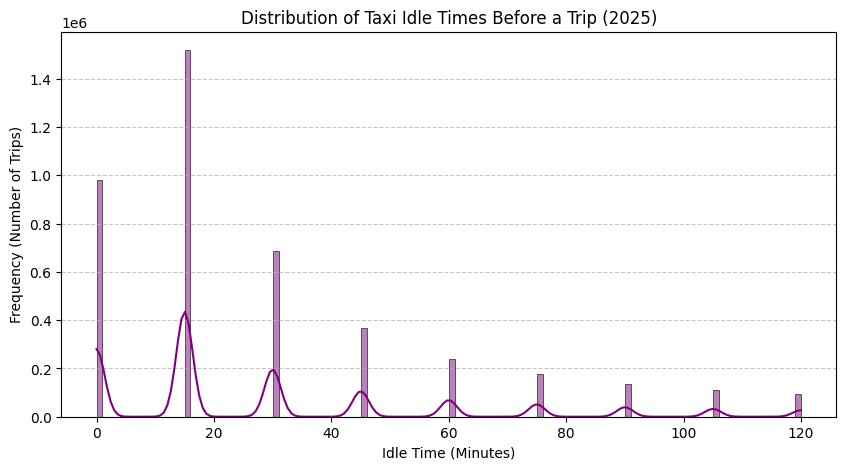

In [11]:
plt.figure(figsize=(10, 5))
# We limit the x-axis to 120 minutes to zoom in on the most common wait times
sns.histplot(trip_data['idle_time_before_start'].dropna(), bins=120, binrange=(0, 120), color='purple', kde=True)

plt.title('Distribution of Taxi Idle Times Before a Trip (2025)')
plt.xlabel('Idle Time (Minutes)')
plt.ylabel('Frequency (Number of Trips)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

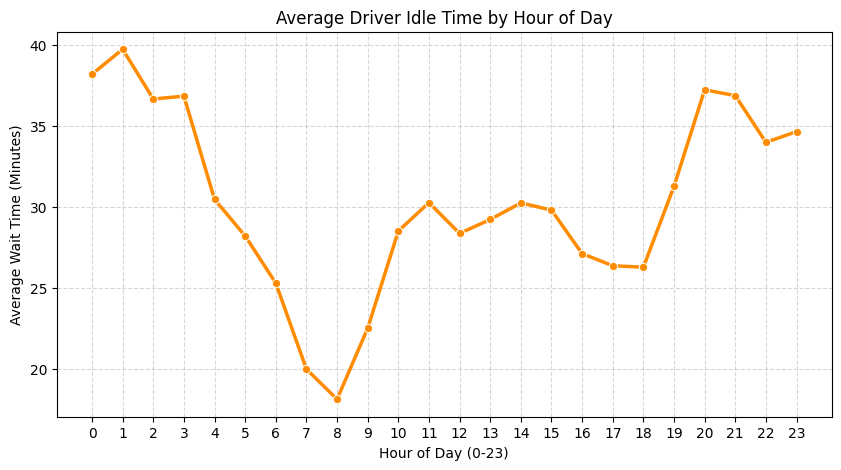

In [12]:
# Calculate the average idle time for each hour of the day
# Pandas naturally ignores our NaNs when calculating the mean!
hourly_idle = trip_data.groupby('start_hour')['idle_time_before_start'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_idle.index, y=hourly_idle.values, marker='o', color='darkorange', linewidth=2.5)

plt.title('Average Driver Idle Time by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Wait Time (Minutes)')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.xticks(range(0, 24))
plt.show()

Now let's take a look at spatial distribution for different h3 resolutions

In [13]:
# 1. Aggregate data by medium resolution hexagon to find the hot zones
hex_counts = trip_data['pickup_h3_medium_resolution'].value_counts().reset_index()
hex_counts.columns = ['hex_id', 'trip_count']

# Take the top 500 busiest hexagons to avoid rendering lag
top_hexagons = hex_counts.head(500).copy()

# 2. Normalize the trip counts for proper color mapping (0 to 1 scale)
max_trips = top_hexagons['trip_count'].max()
min_trips = top_hexagons['trip_count'].min()
top_hexagons['intensity'] = (top_hexagons['trip_count'] - min_trips) / (max_trips - min_trips)

# 3. Initialize a Folium Map centered on Chicago
# Coordinates approx: 41.8781, -87.6298
chicago_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11, tiles="CartoDB positron")

# 4. Convert H3 Hexagon IDs into geographical GeoJSON features
geojson_features = []

for _, row in top_hexagons.iterrows():
    hex_id = row['hex_id']
    count = row['trip_count']
    intensity = row['intensity']
    
    try:
        boundary = h3.cell_to_boundary(hex_id) 
        
        geojson_boundary = [[lng, lat] for lat, lng in boundary]
        # Close the loop for GeoJSON polygon
        geojson_boundary.append(geojson_boundary[0]) 
        
        feature = {
            "type": "Feature",
            "geometry": {
                "type": "Polygon",
                "coordinates": [geojson_boundary]
            },
            "properties": {
                "hex_id": str(hex_id),
                "trip_count": int(count),
                "intensity": float(intensity)
            }
        }
        geojson_features.append(feature)
    except Exception as e:
        print(f"Skipping hex {hex_id} due to error: {e}")
        continue

geojson_data = {"type": "FeatureCollection", "features": geojson_features}

# 5. Define a style function to color hexagons based on demand density
def style_function(feature):
    intensity = feature['properties']['intensity']
    # Color gradient: Yellow (low top demand) to Red (peak demand)
    # Using hex colors for styling
    if intensity > 0.8:
        fill_color = '#d73027' # Deep Red
    elif intensity > 0.5:
        fill_color = '#f46d43' # Orange
    elif intensity > 0.2:
        fill_color = '#fdae61' # Light Orange
    else:
        fill_color = '#fee08b' # Yellow
        
    return {
        'fillColor': fill_color,
        'color': '#666666',      # Border color
        'weight': 1,
        'fillOpacity': 0.6
    }

# 6. Add the Hexagon layer to the map with a popup indicator
geojson_layer = folium.GeoJson(
    geojson_data,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['hex_id', 'trip_count'],
        aliases=['Hexagon ID:', 'Total Trips Filed:'],
        localize=True
    )
)

geojson_layer.add_to(chicago_map)

import base64
from IPython.display import IFrame, display

# 1. Force the map to compile into a raw HTML string
html_string = chicago_map.get_root().render()

# 2. Convert that HTML into a secure base64 string
# This tricks VS Code into treating it as a safe data stream rather than "untrusted script"
encoded_html = base64.b64encode(html_string.encode('utf-8')).decode('utf-8')
data_uri = f"data:text/html;charset=utf-8;base64,{encoded_html}"

# 3. Display the map safely inside an isolated IFrame
display(IFrame(src=data_uri, width="100%", height=500))

In [14]:
# --- SETTINGS FOR LOW RES ---
resolution_col = 'pickup_h3_low_resolution' # Update this to your low-res column name
top_n = 50   # Low res hexes are huge, 50 is more than enough to cover Chicago
zoom = 9     # Zoom out to see the bigger shapes

# 1. Aggregate
hex_counts = trip_data[resolution_col].value_counts().reset_index()
hex_counts.columns = ['hex_id', 'trip_count']
top_hexagons = hex_counts.head(top_n).copy()

# 2. Normalize
max_trips = top_hexagons['trip_count'].max()
min_trips = top_hexagons['trip_count'].min()
top_hexagons['intensity'] = (top_hexagons['trip_count'] - min_trips) / (max_trips - min_trips)

# 3. Map Init
chicago_map_low = folium.Map(location=[41.8781, -87.6298], zoom_start=zoom, tiles="CartoDB positron")

# 4. GeoJSON conversion (Logic remains same)
geojson_features = []
for _, row in top_hexagons.iterrows():
    try:
        boundary = h3.cell_to_boundary(row['hex_id']) 
        geojson_boundary = [[lng, lat] for lat, lng in boundary]
        geojson_boundary.append(geojson_boundary[0]) 
        feature = {
            "type": "Feature",
            "geometry": {"type": "Polygon", "coordinates": [geojson_boundary]},
            "properties": {"hex_id": str(row['hex_id']), "trip_count": int(row['trip_count']), "intensity": float(row['intensity'])}
        }
        geojson_features.append(feature)
    except: continue

# 5. Add Layyer
folium.GeoJson(
    {"type": "FeatureCollection", "features": geojson_features},
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(fields=['trip_count'], aliases=['Trips:'])
).add_to(chicago_map_low)

# 6. Display
html_low = chicago_map_low.get_root().render()
data_uri_low = f"data:text/html;charset=utf-8;base64,{base64.b64encode(html_low.encode('utf-8')).decode('utf-8')}"
display(IFrame(src=data_uri_low, width="100%", height=500))

In [15]:
# --- SETTINGS FOR HIGH RES ---
resolution_col = 'pickup_h3_high_resolution' 
top_n = 5000 # High res needs many hexes to fill the map
zoom = 13     # Zoom in to see street detail

# 1. Aggregate
hex_counts = trip_data[resolution_col].value_counts().reset_index()
hex_counts.columns = ['hex_id', 'trip_count']
top_hexagons = hex_counts.head(top_n).copy()

# 2. Normalize
max_trips = top_hexagons['trip_count'].max()
min_trips = top_hexagons['trip_count'].min()
top_hexagons['intensity'] = (top_hexagons['trip_count'] - min_trips) / (max_trips - min_trips)

# 3. Map Init
chicago_map_high = folium.Map(location=[41.8781, -87.6298], zoom_start=zoom, tiles="CartoDB positron")

# 4. GeoJSON conversion
geojson_features = []
for _, row in top_hexagons.iterrows():
    try:
        boundary = h3.cell_to_boundary(row['hex_id']) 
        geojson_boundary = [[lng, lat] for lat, lng in boundary]
        geojson_boundary.append(geojson_boundary[0]) 
        feature = {
            "type": "Feature",
            "geometry": {"type": "Polygon", "coordinates": [geojson_boundary]},
            "properties": {"hex_id": str(row['hex_id']), "trip_count": int(row['trip_count']), "intensity": float(row['intensity'])}
        }
        geojson_features.append(feature)
    except: continue

# 5. Add Layer
folium.GeoJson(
    {"type": "FeatureCollection", "features": geojson_features},
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(fields=['trip_count'], aliases=['Trips:'])
).add_to(chicago_map_high)

# 6. Display
html_high = chicago_map_high.get_root().render()
data_uri_high = f"data:text/html;charset=utf-8;base64,{base64.b64encode(html_high.encode('utf-8')).decode('utf-8')}"
display(IFrame(src=data_uri_high, width="100%", height=500))

## Static Choropleth Maps

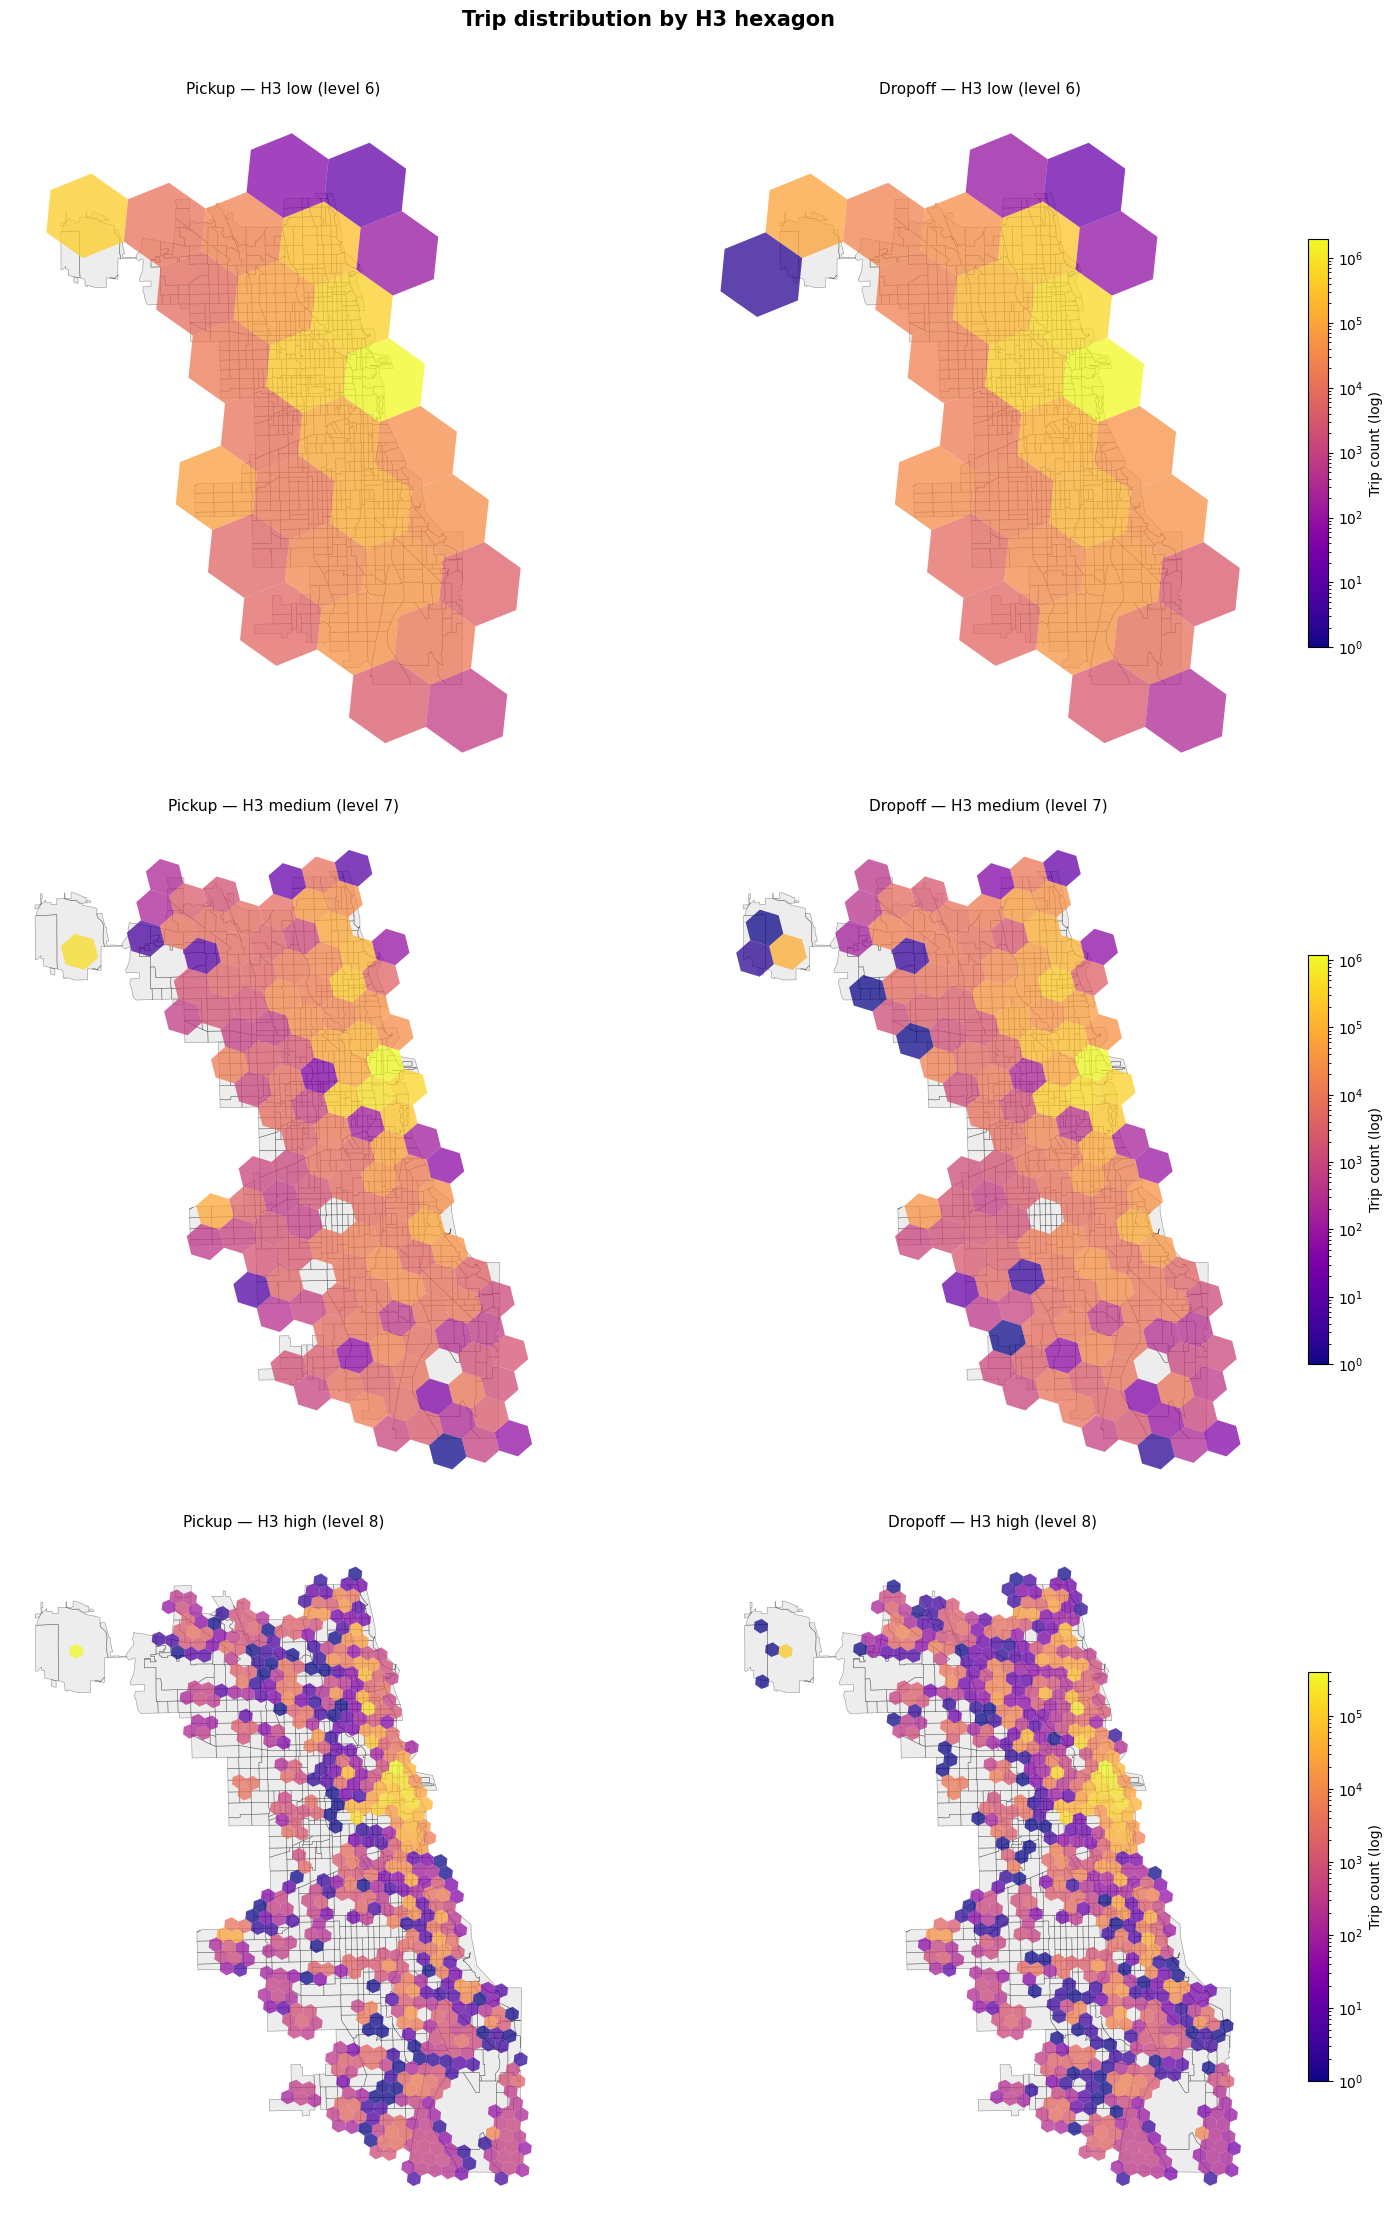

In [27]:
# Static H3 choropleth — all 3 resolutions, pickup and dropoff side by side
resolutions_plot = {'low': 6, 'medium': 7, 'high': 8}
fig, axes = plt.subplots(3, 2, figsize=(16, 22))

for row_idx, (res_name, res_level) in enumerate(resolutions_plot.items()):
    for col_idx, direction in enumerate(('pickup', 'dropoff')):
        ax = axes[row_idx, col_idx]
        counts = trip_data[f'{direction}_h3_{res_name}_resolution'].value_counts().dropna()
        polys = [
            Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])
            for cell in counts.index
        ]
        hex_gdf = gpd.GeoDataFrame({'count': counts.values, 'geometry': polys}, crs=4326)
        tracts.plot(ax=ax, facecolor='lightgray', edgecolor='black', linewidth=0.4, alpha=0.4)
        hex_gdf.plot(
            ax=ax, column='count', cmap='plasma',
            norm=LogNorm(vmin=1, vmax=counts.max()),
            legend=(col_idx == 1),
            legend_kwds={'label': 'Trip count (log)', 'shrink': 0.6},
            alpha=0.75, edgecolor='none'
        )
        ax.set_title(f'{direction.capitalize()} — H3 {res_name} (level {res_level})', fontsize=11)
        ax.set_axis_off()

plt.suptitle('Trip distribution by H3 hexagon', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

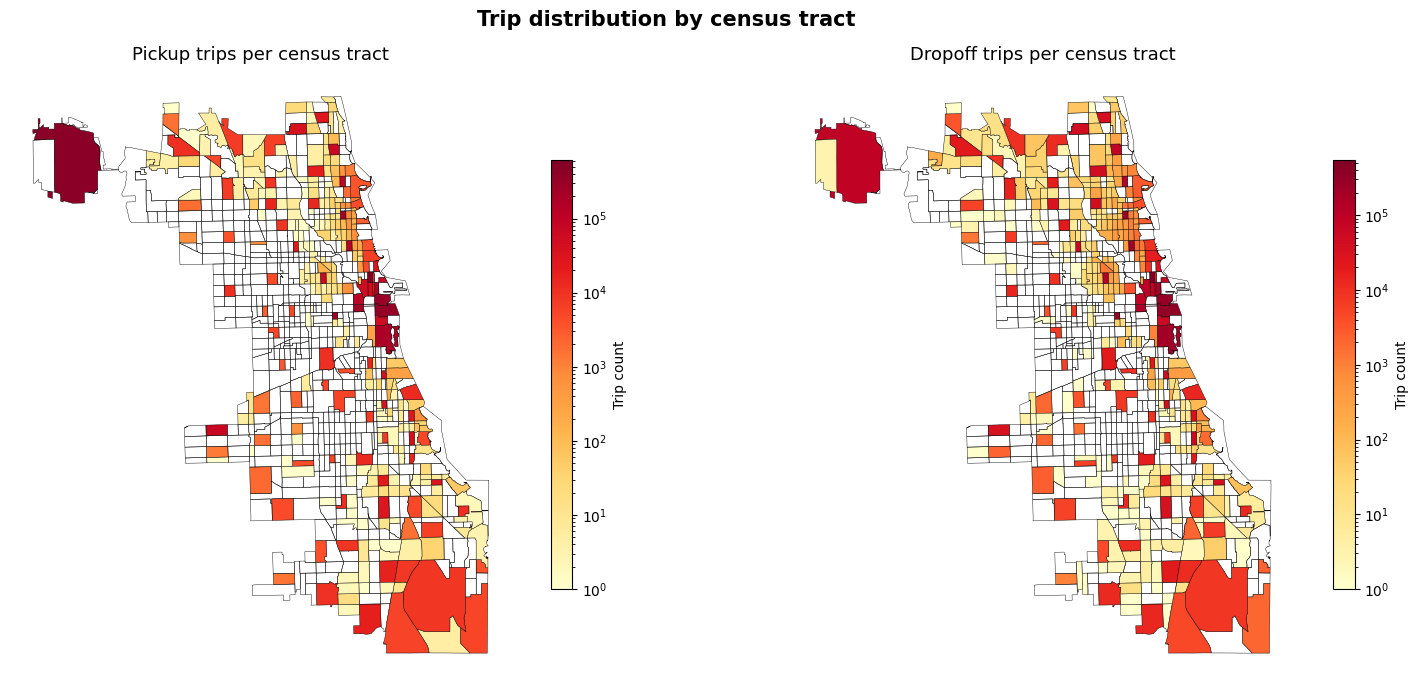

In [28]:
# Census tract choropleth — trip distribution across Chicago's census tracts
pickup_ct  = trip_data['pickup_census_tract'].value_counts().rename('count')
dropoff_ct = trip_data['dropoff_census_tract'].value_counts().rename('count')

pickup_ct.index  = pickup_ct.index.map(lambda x: str(int(x)))
dropoff_ct.index = dropoff_ct.index.map(lambda x: str(int(x)))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, counts, title in zip(
    axes,
    [pickup_ct, dropoff_ct],
    ['Pickup trips per census tract', 'Dropoff trips per census tract']
):
    plot_gdf = tracts[[TRACT_COL, 'geometry']].copy()
    plot_gdf['count'] = plot_gdf[TRACT_COL].map(counts).fillna(0).astype(int)
    plot_gdf.plot(
        ax=ax, column='count', cmap='YlOrRd',
        norm=LogNorm(vmin=max(1, plot_gdf['count'][plot_gdf['count'] > 0].min()),
                     vmax=plot_gdf['count'].max()),
        legend=True, legend_kwds={'label': 'Trip count', 'shrink': 0.7},
        edgecolor='black', linewidth=0.3
    )
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()

plt.suptitle('Trip distribution by census tract', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

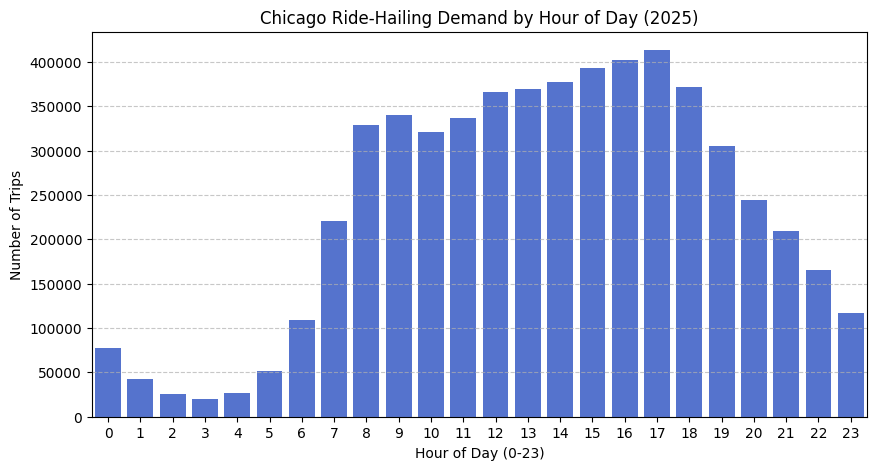

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate hourly distribution
hourly_counts = trip_data['start_hour'].value_counts().sort_index()

# Plot the hourly demand
plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, color='royalblue')
plt.title('Chicago Ride-Hailing Demand by Hour of Day (2025)')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure trip_start_timestamp is converted to datetime
trip_data['trip_start_timestamp'] = pd.to_datetime(trip_data['trip_start_timestamp'])

# 2. Extract day name
trip_data['day_name'] = trip_data['trip_start_timestamp'].dt.day_name()

# Define categorical orders so your charts don't sort alphabetically (e.g., Friday before Monday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

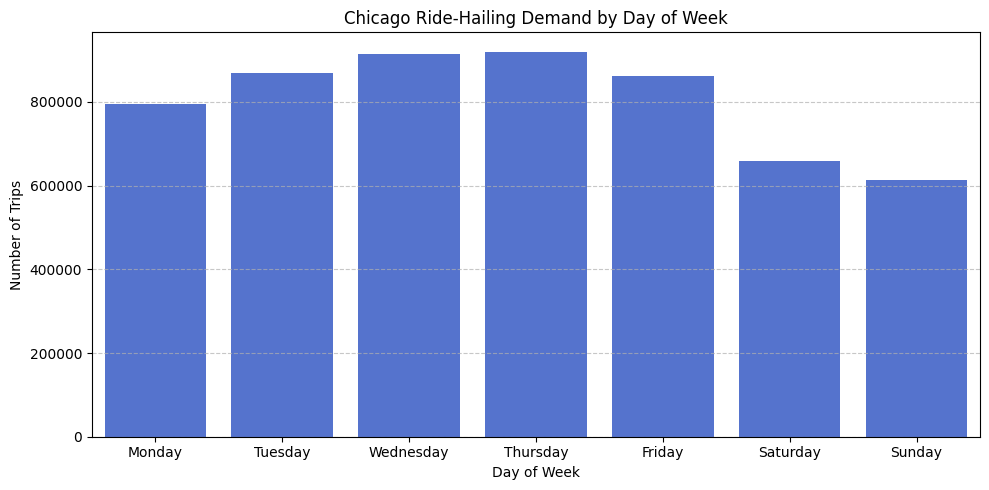

In [20]:
# Calculate day of week distribution and reindex to force Mon->Sun order
dow_counts = trip_data['day_name'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=dow_counts.index, y=dow_counts.values, color='royalblue')
plt.title('Chicago Ride-Hailing Demand by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

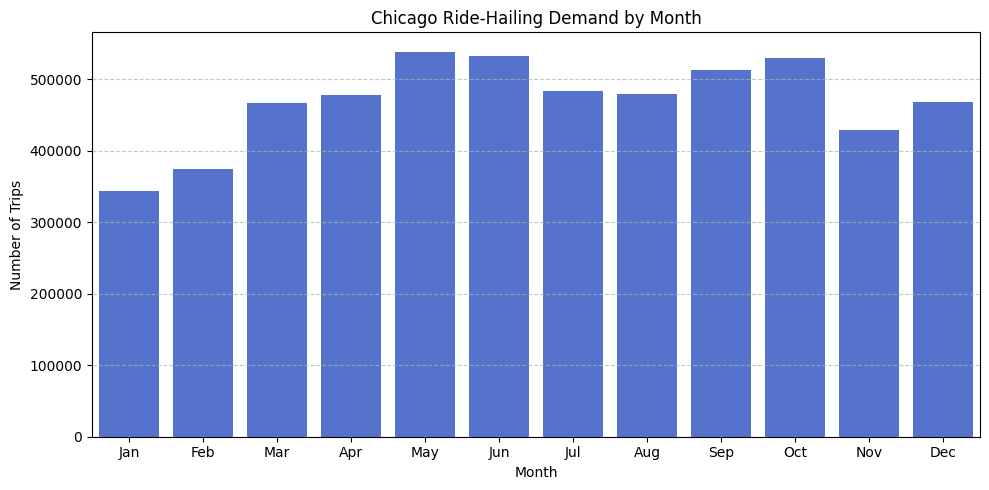

In [21]:
# Calculate monthly distribution
month_counts = trip_data['start_month'].value_counts().sort_index()

# Map the numeric indices (1-12) to month names (Jan-Dec)
x_labels = [month_names[m - 1] for m in month_counts.index]

plt.figure(figsize=(10, 5))
sns.barplot(x=x_labels, y=month_counts.values, color='royalblue')
plt.title('Chicago Ride-Hailing Demand by Month')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

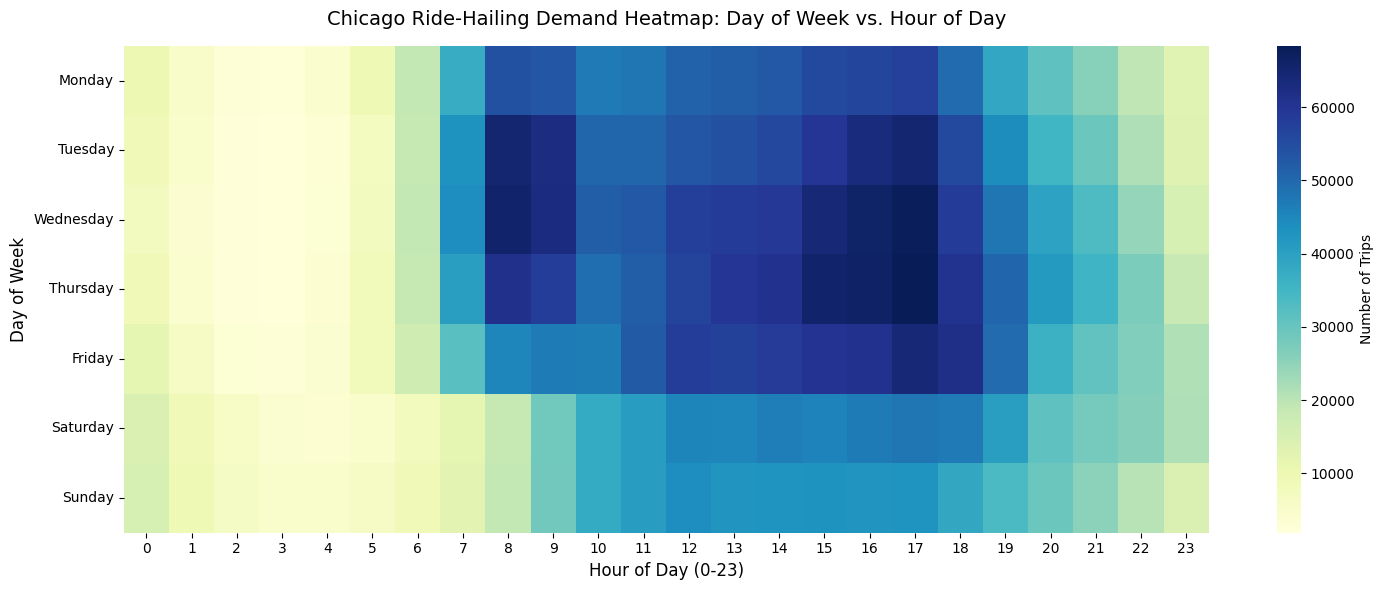

In [22]:
# Create a pivot table counting trips (using trip_id as the counter)
heatmap_data = trip_data.pivot_table(
    index='day_name', 
    columns='start_hour', 
    values='trip_id', 
    aggfunc='count'
).reindex(day_order) # Ensures Monday to Sunday top-down order

plt.figure(figsize=(15, 6))
# 'YlGnBu' (Yellow-Green-Blue) is highly readable for density/demand
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, fmt="d", cbar_kws={'label': 'Number of Trips'})

plt.title('Chicago Ride-Hailing Demand Heatmap: Day of Week vs. Hour of Day', fontsize=14, pad=15)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# 1. Create a new column for trip duration in minutes
trip_data['trip_minutes'] = trip_data['trip_seconds'] / 60

# 2. Configure pandas to format float outputs cleanly (suppressing scientific notation)
# This rounds numbers to 2 decimal places across the board
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 3. Select our operational columns (swapping seconds for minutes)
operational_cols = ['trip_miles', 'trip_minutes', 'trip_total']

# 4. Generate the clean percentile breakdown
operational_summary = trip_data[operational_cols].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

# Rename the index/columns for presentation-ready output
operational_summary.columns = ['Trip Distance (Miles)', 'Trip Duration (Minutes)', 'Total Ticket ($)']
print("=== Fleet Operations Analysis Summary ===")
print(operational_summary)

=== Fleet Operations Analysis Summary ===
       Trip Distance (Miles)  Trip Duration (Minutes)  Total Ticket ($)
count             5634139.00               5634139.00        5634139.00
mean                    6.46                    20.44             24.31
std                     6.50                    23.78             19.87
min                     0.01                     1.00              0.01
25%                     1.32                     8.70             10.15
50%                     3.19                    14.97             15.50
75%                    11.32                    26.73             32.50
90%                    17.07                    42.00             56.00
95%                    18.04                    52.82             61.20
99%                    23.30                    75.93             79.20
max                   781.60                  1439.93           6950.69


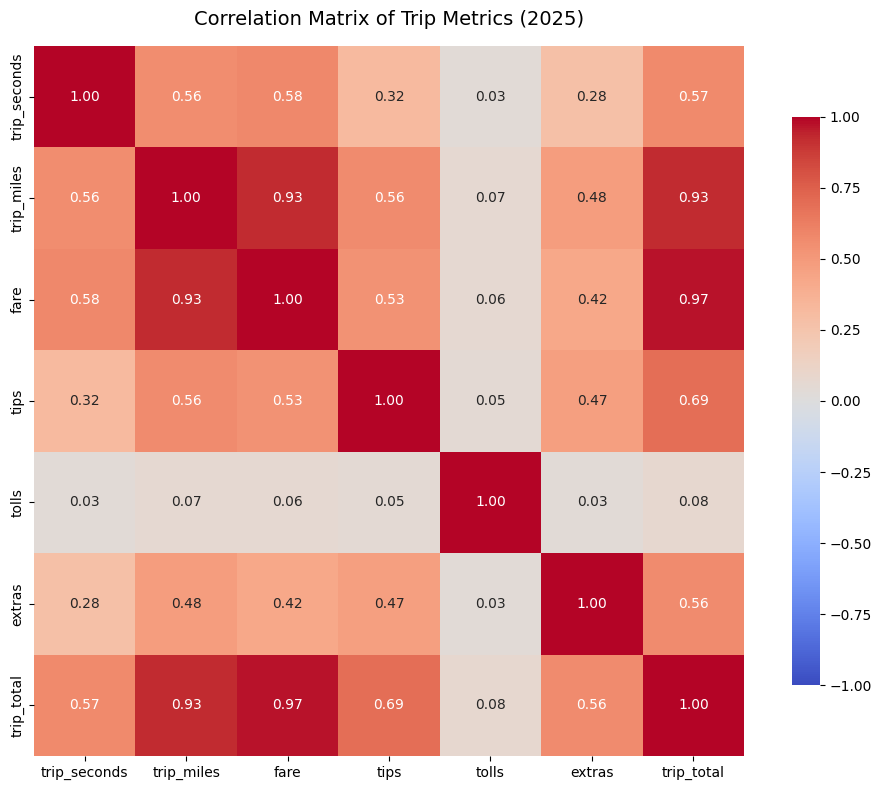

In [24]:
# 1. Isolate the true numeric continuous features
trip_numeric_cols = [
    'trip_seconds', 'trip_miles', 'fare', 
    'tips', 'tolls', 'extras', 'trip_total'
]

# Calculate correlation on the 5.5 million rows (focusing only on these columns is fast!)
trip_corr = trip_data[trip_numeric_cols].corr()

# 2. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    trip_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    square=True, 
    vmin=-1, vmax=1, # Forces scale from -1 to 1
    cbar_kws={'shrink': .8}
)

plt.title('Correlation Matrix of Trip Metrics (2025)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()